In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### **Reading Data**

In [2]:
customers = pd.read_csv('../data/processed/customers_clean.csv')
orders = pd.read_csv('../data/processed/orders_clean.csv')
order_items = pd.read_csv('../data/processed/order_items_clean.csv')
order_payments = pd.read_csv('../data/processed/order_payments_clean.csv')
order_reviews = pd.read_csv('../data/processed/order_reviews_clean.csv')
products = pd.read_csv('../data/processed/products_clean.csv')
sellers = pd.read_csv('../data/processed/sellers_clean.csv')
locations = pd.read_csv('../data/processed/locations_clean.csv')
product_category = pd.read_csv('../data/processed/product_category_clean.csv')

### **Monthly Sales Trend**

In [3]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [4]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [6]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
sales=orders.merge(order_items, on='order_id')

In [8]:
sales=sales[sales['order_status']=='delivered']

In [16]:
sales['order_month']=sales['order_purchase_timestamp'].dt.to_period('M')
sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018-02


In [10]:
monthly_revenue=sales.groupby('order_month')['price'].sum()
monthly_revenue

order_month
2016-09       134.97
2016-10     40325.11
2016-12        10.90
2017-01    111798.36
2017-02    234223.40
2017-03    359198.85
2017-04    340669.68
2017-05    489338.25
2017-06    421923.37
2017-07    481604.52
2017-08    554699.70
2017-09    607399.67
2017-10    648247.65
2017-11    987765.37
2017-12    726033.19
2018-01    924645.00
2018-02    826437.13
2018-03    953356.25
2018-04    973534.09
2018-05    977544.69
2018-06    856077.86
2018-07    867953.46
2018-08    838576.64
Freq: M, Name: price, dtype: float64

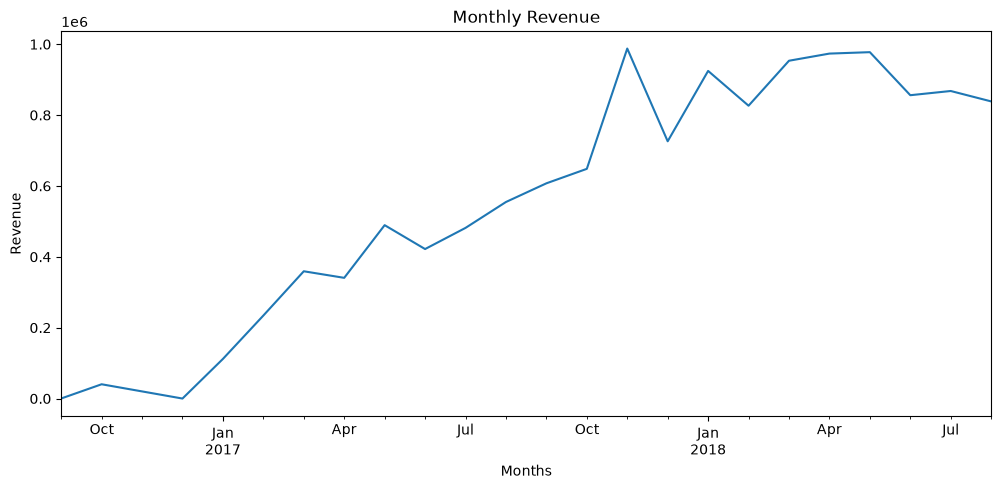

In [11]:
monthly_revenue.plot(kind='line',figsize=(12,5),title='Monthly Revenue')
plt.ylabel('Revenue')
plt.xlabel('Months')
plt.show()

In [12]:
daily_revenue=sales.groupby(sales['order_purchase_timestamp'].dt.floor('D'))['price'].sum()
daily_revenue.sort_index(inplace=True)

In [13]:
daily_revenue.loc['2017-11-01':'2017-11-30'].sort_values(ascending=False).head(10)

order_purchase_timestamp
2017-11-24    149916.58
2017-11-25     59928.51
2017-11-28     47694.76
2017-11-27     47237.27
2017-11-26     44000.48
2017-11-20     43405.98
2017-11-23     43102.33
2017-11-29     39093.09
2017-11-21     33600.85
2017-11-30     30835.85
Name: price, dtype: float64

**Finding:** Daily revenue peaked on November 24, 2017 at $152,653.74, roughly 2.5x higher than the next-highest day in the month (Nov 25: $60,923.48) and 3-4x a typical November day ($35-48k). November 24, 2017 was Black Friday 
in Brazil, making this the clear driver of the November revenue spike seen in 
the monthly trend chart.

### **Product Category Performance**

In [14]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
product_sales=sales.merge(products, on='product_id',how='left')
product_sales=product_sales.merge(product_category, on='product_category_name',how='left')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,order_month,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,2017-10,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,2018-07,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,2018-08,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,2017-11,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,2018-02,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


**Top Category By Revenue**

In [34]:
catergory_revenue=product_sales.groupby('product_category_name_english')['price'].sum()
catergory_revenue=catergory_revenue.sort_values(ascending=False).head(10)

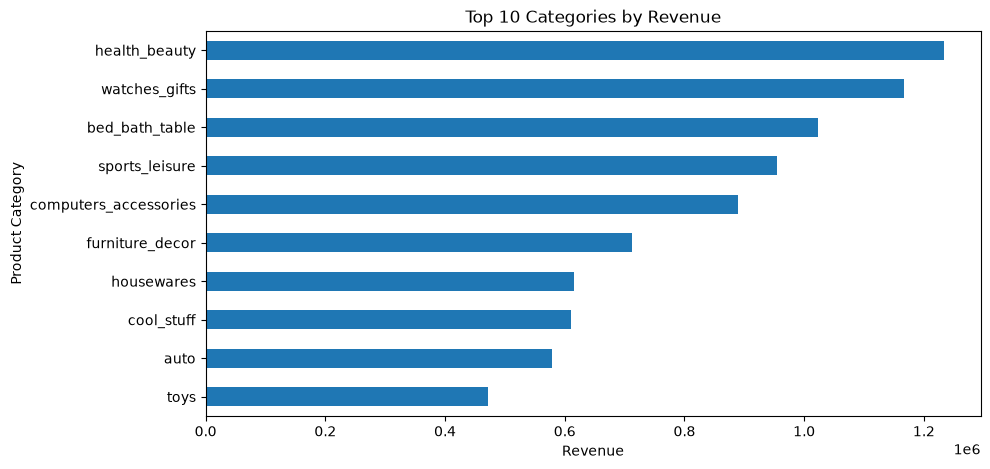

In [35]:
catergory_revenue.head(10).plot(kind='barh',figsize=(10,5),title='Top 10 Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.gca().invert_yaxis()
plt.show()

**Number of Items Sold per Category**

In [38]:
order_count=product_sales.groupby('product_category_name_english')['order_id'].count().sort_values(ascending=False).head(10)
order_count

product_category_name_english
bed_bath_table           10953
health_beauty             9465
sports_leisure            8431
furniture_decor           8160
computers_accessories     7644
housewares                6795
watches_gifts             5859
telephony                 4430
garden_tools              4268
auto                      4140
Name: order_id, dtype: int64

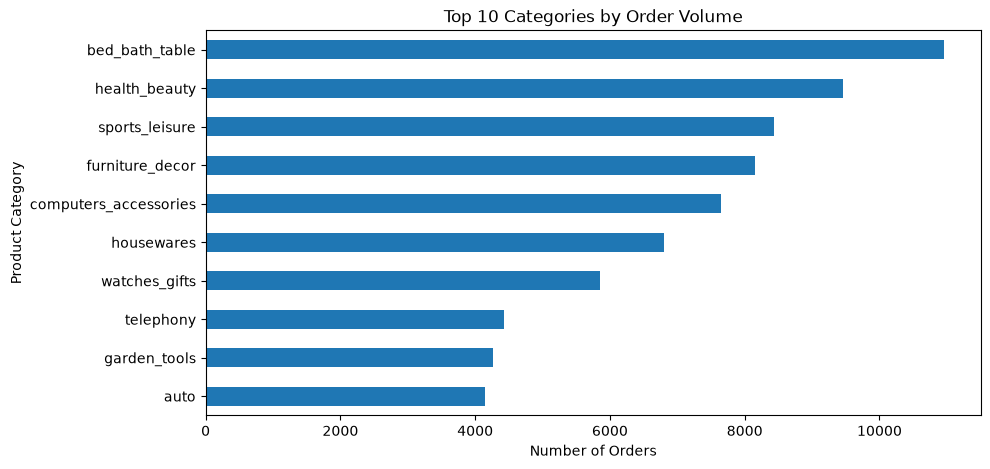

In [39]:
order_count.head(10).plot(kind='barh',figsize=(10,5),title='Top 10 Categories by Order Volume')
plt.xlabel('Number of Orders')
plt.ylabel('Product Category')
plt.gca().invert_yaxis()
plt.show()

**Average Price per Order**

In [41]:
catergory_revenue_full=product_sales.groupby('product_category_name_english')['price'].sum()
order_count_full=product_sales.groupby('product_category_name_english')['order_id'].count()

avg_price_per_order = (catergory_revenue_full / order_count_full).sort_values(ascending=False)
avg_price_per_order.head(10)

product_category_name_english
computers                                1098.915276
small_appliances_home_oven_and_coffee     638.213151
home_appliances_2                         467.333117
agro_industry_and_commerce                342.553883
musical_instruments                       283.127097
small_appliances                          277.741824
fixed_telephony                           216.922392
construction_tools_safety                 211.875519
watches_gifts                             199.040276
furniture_bedroom                         184.968932
dtype: float64

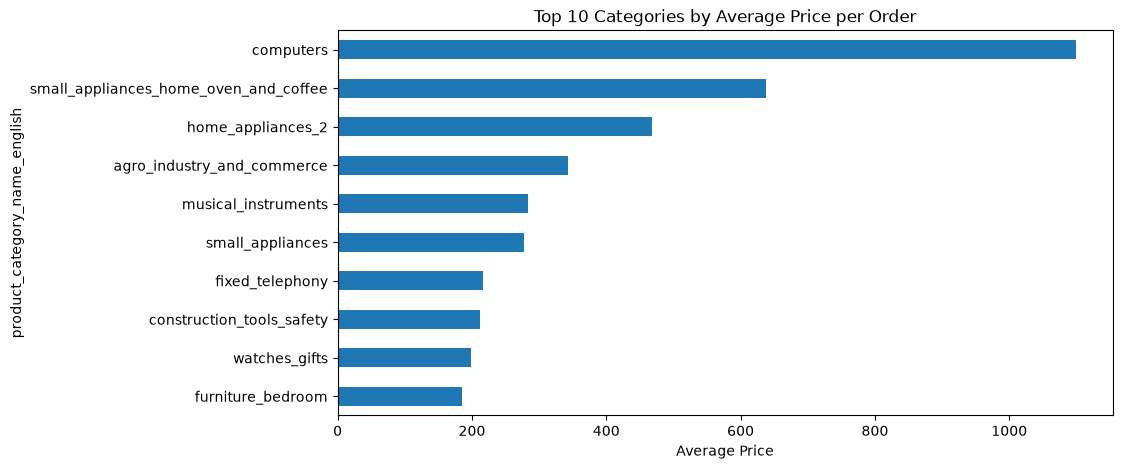

In [42]:
avg_price_per_order.head(10).plot(kind='barh', figsize=(10,5), title='Top 10 Categories by Average Price per Order')
plt.xlabel('Average Price')
plt.gca().invert_yaxis()
plt.show()

**Finding:** Average price per order varies far more sharply across categories 
than total revenue alone. computers has by far the highest average 
order value ($1,098.92), over 5x higher than the 9th-ranked watches_gifts 
($199.04), despite not appearing in the top 10 by total revenue, indicating 
it's a low-volume, high-value niche category. This shows that "top category" 
depends heavily on which metric is used: bed_bath_table leads by volume, 
health_beauty leads by total revenue, and computers leads by price-per-order,
three different categories.